# Task 1 — Baseline Strategy


## Overview And Research Purpose
This notebook documents the Task 1 baseline commodity trend-following strategy. It loads training prices, runs the baseline signal and portfolio pipeline, inspects signal quality, reviews position and risk behavior, and reports performance robustness. It is intentionally a training research notebook; final holdout evaluation should be run separately.


## 0. Imports And Data Loading
Set up local imports, load the Task 1 training inputs, and create the equal-weight commodity factor used as a comparison benchmark.


In [80]:
%load_ext autoreload
%autoreload 2

import sys, os, warnings
from pathlib import Path
warnings.filterwarnings('ignore')

ROOT = Path(os.path.abspath('')).parents[1]
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / 'tasks' / 'task_1'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.grid']  = True
plt.rcParams['grid.alpha'] = 0.25

from strategy import build_signals, run_strategy
from analytics   import (performance_stats, sector_contribution,
                          position_summary, plot_signals,
                          rolling_sharpe, plot_rolling_sharpe)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [81]:
prices = pd.read_csv(ROOT / 'data/training/close_prices_final.csv',
                     index_col=0, parse_dates=True).sort_index()

returns = prices.pct_change()
assets  = pd.read_csv(ROOT / 'data/raw/assets.csv')
factor  = returns.mean(axis=1)
factor.name = 'EW Factor'

print(f'Period      : {prices.index[0].date()} → {prices.index[-1].date()}')
print(f'Commodities : {prices.shape[1]}')
print(f'Days        : {len(prices):,}')
print(f'Price type  : actual futures closing prices (from Commodities Data xlsx)')

Period      : 2005-10-05 → 2019-12-31
Commodities : 23
Days        : 3,715
Price type  : actual futures closing prices (from Commodities Data xlsx)


## 1. Control Panel
Central parameter block for the baseline strategy. These values feed the signal layers, stop logic, sizing, and execution lag used below.


In [82]:
# ── Layer 1 — Regime filter ────────────────────────────────────────────────────
FILTER_FAST    = 50      # SMA fast period
FILTER_SLOW    = 200     # SMA slow period
SLOPE_LOOKBACK = 100     # SMA200 slope window (days)

# ── Layer 2 — Entry timing ─────────────────────────────────────────────────────
EMA_WINDOW      = 14     # EMA cross window
RSI_WINDOW      = 14     # RSI period
RSI_LONG_LEVEL  = 50.0   # RSI must cross ABOVE this to confirm long
RSI_LEVEL       = 60.0   # RSI must cross BELOW this to confirm short
RSI_FLAG_WINDOW = 5      # days the RSI flag stays active after the break

# ── Slot manager — Exit conditions ─────────────────────────────────────────────
BB_WINDOW  = 100    # Bollinger Band period
BB_NUM_STD = 2.0    # Bollinger Band std multiplier
ATR_WINDOW = 50     # ATR lookback (50-day rolling mean abs return)
SL_MULT    = 3.0    # Stop Loss = entry_price × (1 ± SL_MULT × ATR_pct)

# ── Portfolio manager — sizing and risk ────────────────────────────────────────
RISK_PER_TRADE = 0.01    # capital fraction risked per trade (1%)
MAX_WEIGHT     = 0.20    # hard cap on individual position weight (20%)
LEVERAGE_CAP   = 2.50    # gross leverage cap (250%)

## 2. Strategy Run
Run the full Task 1 baseline pipeline once with the control-panel parameters. Downstream diagnostics use these `positions`, `weights`, and `port_r` objects.


In [83]:
positions, weights, port_r = run_strategy(
    prices,
    returns = returns,
    # Layer 1
    filter_fast    = FILTER_FAST,
    filter_slow    = FILTER_SLOW,
    slope_lookback = SLOPE_LOOKBACK,
    # Layer 2
    ema_window      = EMA_WINDOW,
    rsi_window      = RSI_WINDOW,
    rsi_long_level  = RSI_LONG_LEVEL,
    rsi_level       = RSI_LEVEL,
    rsi_flag_window = RSI_FLAG_WINDOW,
    # Slot manager — exits
    bb_window  = BB_WINDOW,
    bb_num_std = BB_NUM_STD,
    atr_window = ATR_WINDOW,
    sl_mult    = SL_MULT,
    # Portfolio manager — sizing
    risk_per_trade = RISK_PER_TRADE,
    max_weight     = MAX_WEIGHT,
    leverage_cap   = LEVERAGE_CAP,
)

## 3. Signal Diagnostics
The next cells inspect whether the two signal layers behave as intended before looking at portfolio performance.

### 3.1 Layer 1 Regime Filter
Measure how often the baseline regime filter is long, short, or neutral by commodity.


In [84]:
from tasks.task_1.signals.signal_layer1 import layer1_signal

l1 = layer1_signal(prices,
                   filter_fast    = FILTER_FAST,
                   filter_slow    = FILTER_SLOW,
                   slope_lookback = SLOPE_LOOKBACK)

print(f'prices : {prices.shape}   id={id(prices)}')
print(f'l1     : {l1.shape}   id={id(l1)}  ← separate object, prices unchanged')
print(f'Values : -1 (Short)  0 (Neutral)  +1 (Long)  NaN (warmup SMA{FILTER_SLOW})')
print()

total = len(l1)
counts_df = pd.DataFrame({
    'Long (+1)'    : (l1 ==  1).sum(),
    'Neutral (0)'  : (l1 ==  0).sum(),
    'Short (-1)'   : (l1 == -1).sum(),
    'NaN (warmup)' : l1.isna().sum(),
    '% Long'       : ((l1 ==  1).sum() / total * 100).round(1),
    '% Neutral'    : ((l1 ==  0).sum() / total * 100).round(1),
    '% Short'      : ((l1 == -1).sum() / total * 100).round(1),
})
counts_df.index.name = 'Commodity'
display(counts_df)

prices : (3715, 23)   id=4820700528
l1     : (3715, 23)   id=5018404048  ← separate object, prices unchanged
Values : -1 (Short)  0 (Neutral)  +1 (Long)  NaN (warmup SMA200)



,Long (+1),Neutral (0),Short (-1),NaN (warmup),% Long,% Neutral,% Short
Commodity,,,,,,,
LIVE CATTLE,996,869,1551,299,26.8,23.4,41.7
LEAN HOGS,439,1092,1885,299,11.8,29.4,50.7
COFFEE 'C',737,825,1854,299,19.8,22.2,49.9
CORN,709,756,1951,299,19.1,20.3,52.5
COTTON NO.2,1226,889,1301,299,33.0,23.9,35.0
SOYBEAN,1273,949,1194,299,34.3,25.5,32.1
SUGAR #11,665,848,1903,299,17.9,22.8,51.2
WHEAT FUTURE,599,739,2078,299,16.1,19.9,55.9
BRENT CRUDE,1650,842,924,299,44.4,22.7,24.9


### 3.2 Layer 1 Regime Accuracy Chart
Visualise whether the persistent regime signal tends to align with forward commodity returns.


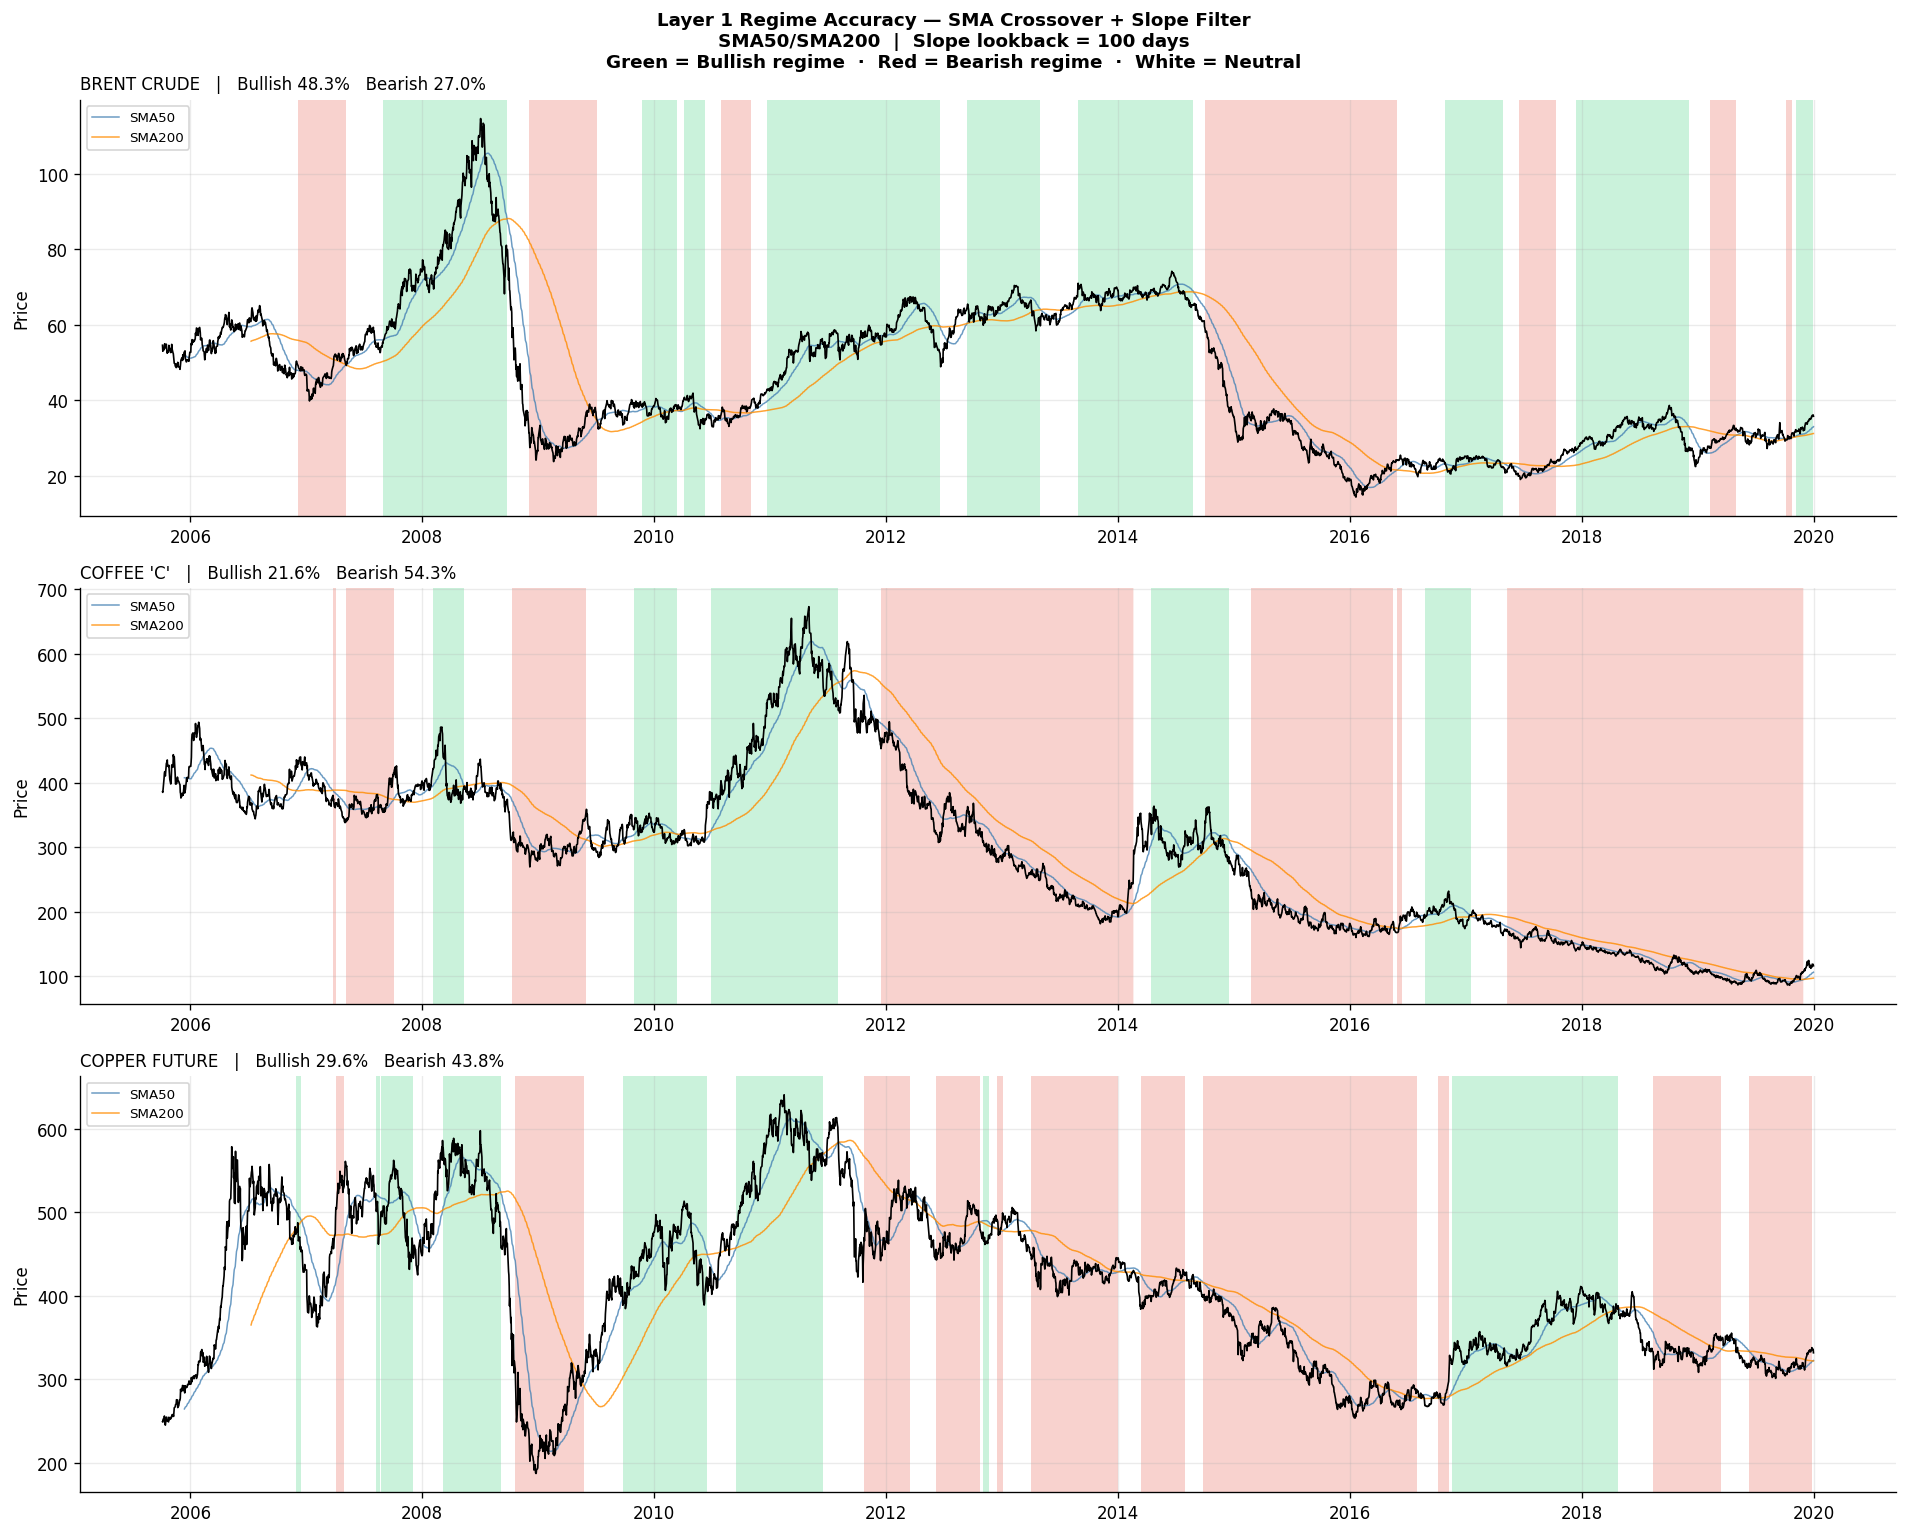

In [85]:
from tasks.task_1.signals.signal_layer1 import layer1_signal

l1 = layer1_signal(prices, filter_fast=FILTER_FAST, filter_slow=FILTER_SLOW,
                   slope_lookback=SLOPE_LOOKBACK)

REGIME_COMDTIES = ['BRENT CRUDE', "COFFEE 'C'", 'COPPER FUTURE']

fig, axes = plt.subplots(3, 1, figsize=(16, 13), sharex=False)
fig.suptitle(
    f'Layer 1 Regime Accuracy — SMA Crossover + Slope Filter\n'
    f'SMA{FILTER_FAST}/SMA{FILTER_SLOW}  |  Slope lookback = {SLOPE_LOOKBACK} days\n'
    f'Green = Bullish regime  ·  Red = Bearish regime  ·  White = Neutral',
    fontweight='bold', fontsize=11
)

for ax, col in zip(axes, REGIME_COMDTIES):
    p   = prices[col]
    sig = l1[col]

    sma_fast = p.rolling(FILTER_FAST).mean()
    sma_slow = p.rolling(FILTER_SLOW).mean()

    ax.plot(p.index, p.values,        color='black',      lw=1.0, zorder=3)
    ax.plot(p.index, sma_fast.values, color='steelblue',  lw=0.9, alpha=0.8,
            label=f'SMA{FILTER_FAST}')
    ax.plot(p.index, sma_slow.values, color='darkorange',  lw=0.9, alpha=0.8,
            label=f'SMA{FILTER_SLOW}')

    ax.fill_between(p.index, 0, 1,
                    where=(sig == 1),
                    transform=ax.get_xaxis_transform(),
                    color='#2ecc71', alpha=0.25, lw=0, zorder=1)
    ax.fill_between(p.index, 0, 1,
                    where=(sig == -1),
                    transform=ax.get_xaxis_transform(),
                    color='#e74c3c', alpha=0.25, lw=0, zorder=1)

    n_total  = sig.notna().sum()
    pct_bull = (sig ==  1).sum() / n_total * 100
    pct_bear = (sig == -1).sum() / n_total * 100

    ax.set_title(f'{col}   |   Bullish {pct_bull:.1f}%   Bearish {pct_bear:.1f}%',
                 fontsize=10, loc='left')
    ax.legend(fontsize=8, loc='upper left')
    ax.set_ylabel('Price')
    ax.spines[['top', 'right']].set_visible(False)

fig.tight_layout()
plt.show()

### 3.3 Layer 2 Entry Signals
Count entry events produced by the EMA and RSI timing layer inside the Layer 1 regime.


Layer 2 entry signal counts per commodity:


,Long (+1),Short (-1),Total
Commodity,,,
LIVE CATTLE,37,31,68
LEAN HOGS,12,44,56
COFFEE 'C',33,37,70
CORN,23,39,62
COTTON NO.2,56,29,85
SOYBEAN,49,31,80
SUGAR #11,27,46,73
WHEAT FUTURE,24,46,70
BRENT CRUDE,70,27,97


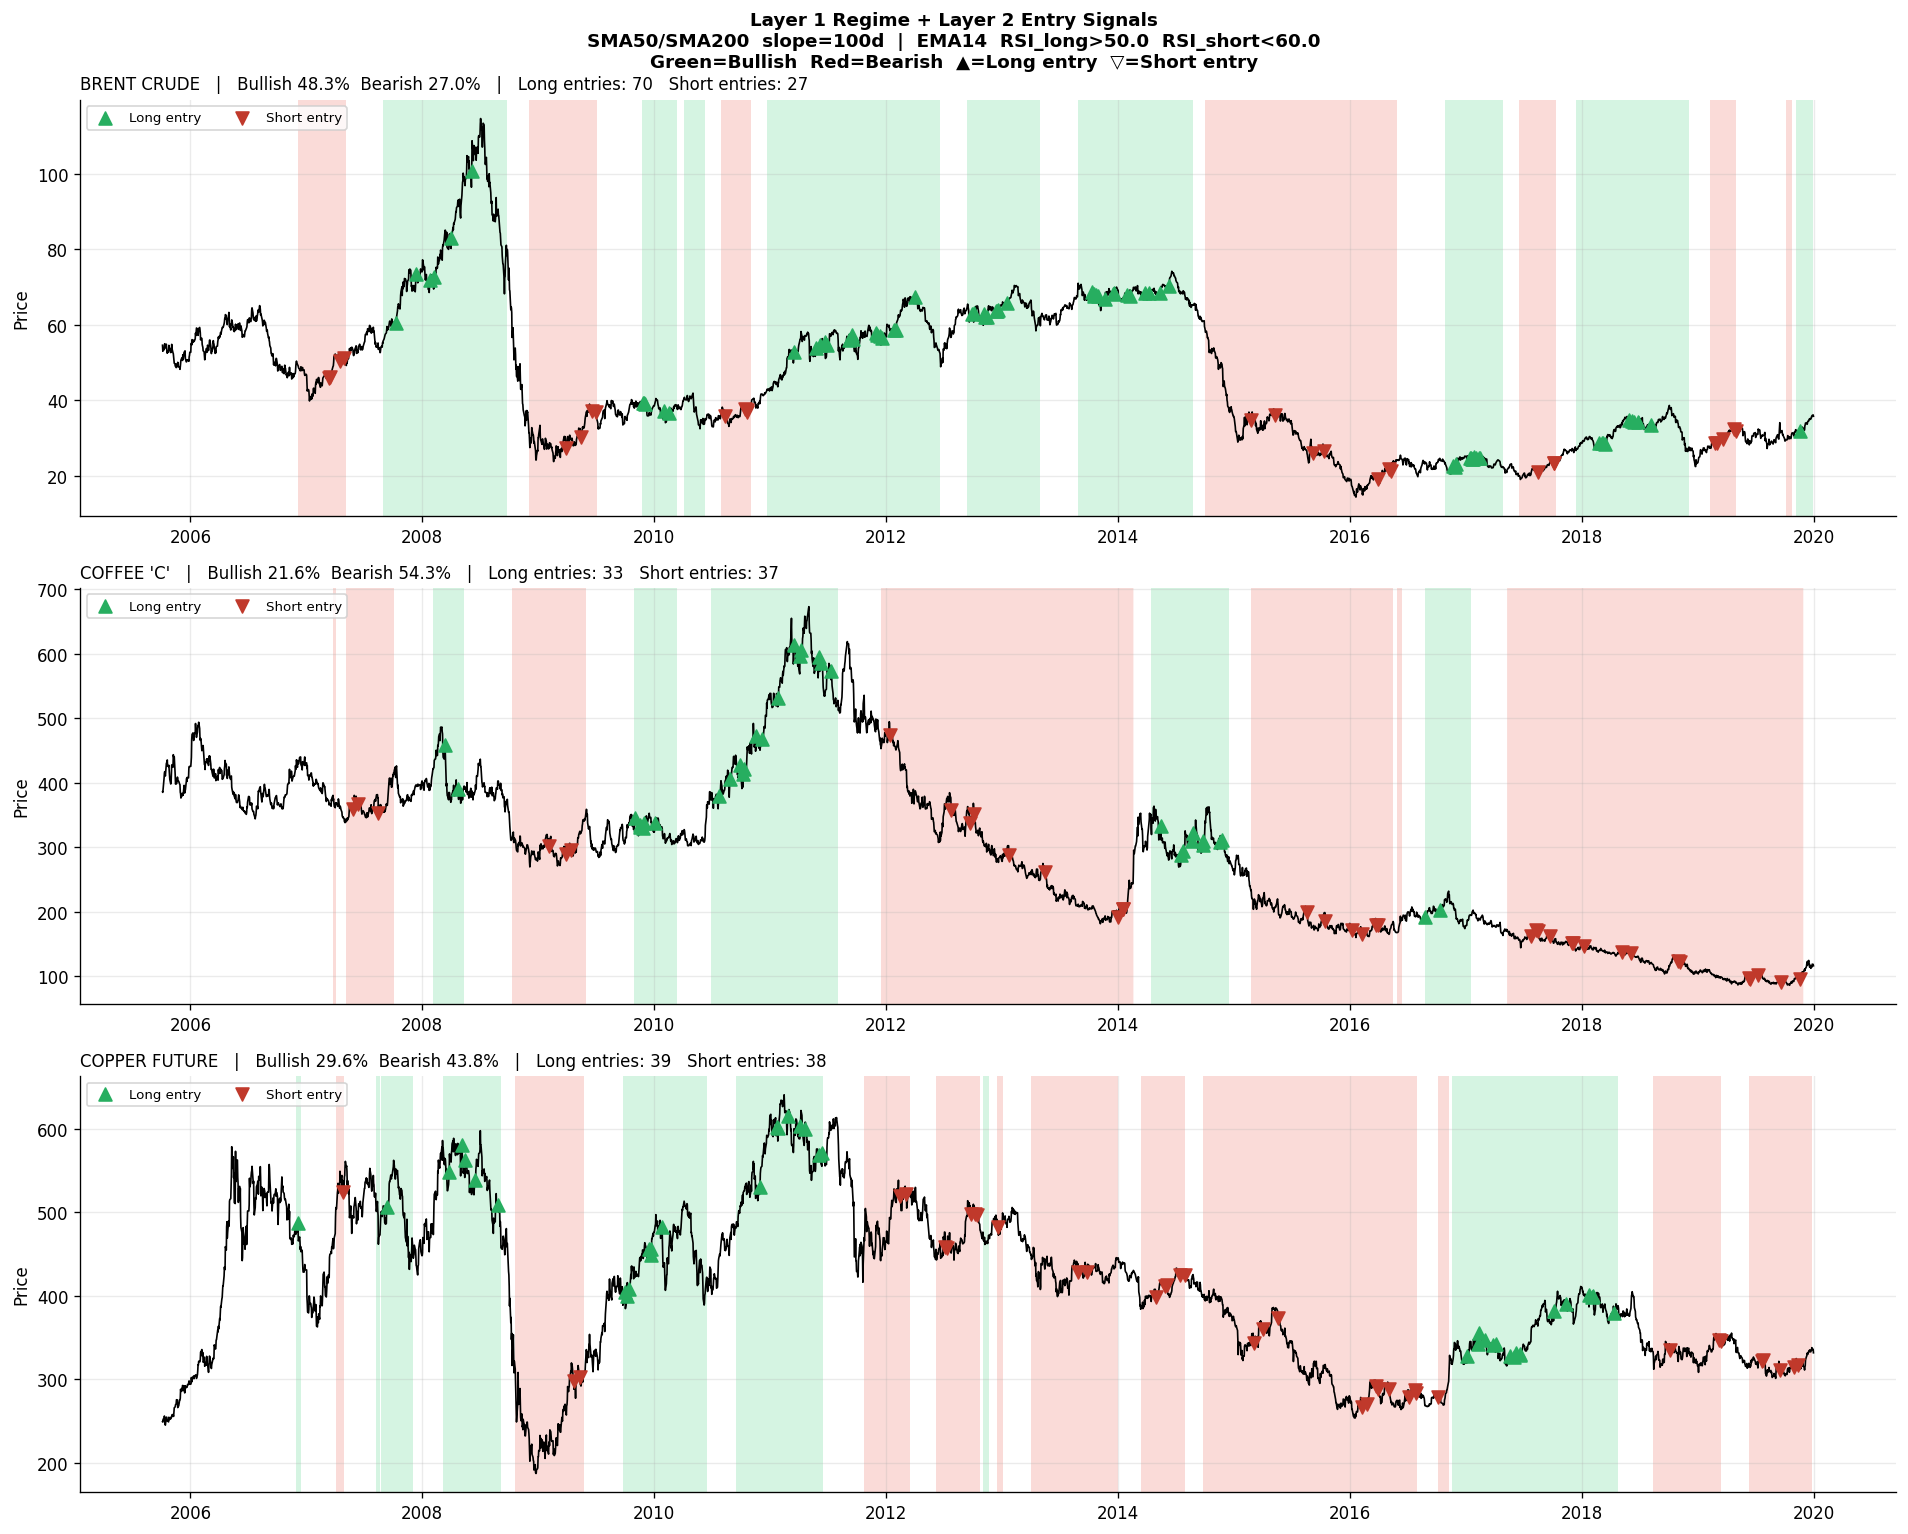

In [86]:
from tasks.task_1.signals.signal_layer1 import layer1_signal
from tasks.task_1.signals.signal_layer2 import layer2_signal
import matplotlib.patches as mpatches

l1 = layer1_signal(prices, filter_fast=FILTER_FAST, filter_slow=FILTER_SLOW,
                   slope_lookback=SLOPE_LOOKBACK)
l2 = layer2_signal(prices, layer1=l1,
                   ema_window=EMA_WINDOW, rsi_window=RSI_WINDOW,
                   rsi_long_level=RSI_LONG_LEVEL, rsi_level=RSI_LEVEL,
                   rsi_flag_window=RSI_FLAG_WINDOW)

sig_table = pd.DataFrame({
    'Long  (+1)' : (l2 ==  1).sum(),
    'Short (-1)' : (l2 == -1).sum(),
    'Total'      : ((l2 == 1) | (l2 == -1)).sum(),
})
sig_table.index.name = 'Commodity'
print('Layer 2 entry signal counts per commodity:')
display(sig_table)

REGIME_COMDTIES = ['BRENT CRUDE', "COFFEE 'C'", 'COPPER FUTURE']

fig, axes = plt.subplots(3, 1, figsize=(16, 13), sharex=False)
fig.suptitle(
    f'Layer 1 Regime + Layer 2 Entry Signals\n'
    f'SMA{FILTER_FAST}/SMA{FILTER_SLOW}  slope={SLOPE_LOOKBACK}d  |  '
    f'EMA{EMA_WINDOW}  RSI_long>{RSI_LONG_LEVEL}  RSI_short<{RSI_LEVEL}\n'
    f'Green=Bullish  Red=Bearish  ▲=Long entry  ▽=Short entry',
    fontweight='bold', fontsize=11
)

for ax, col in zip(axes, REGIME_COMDTIES):
    p    = prices[col]
    sig1 = l1[col]
    sig2 = l2[col]

    ax.plot(p.index, p.values, color='black', lw=1.0, zorder=3)
    ax.fill_between(p.index, 0, 1, where=(sig1 == 1),
                    transform=ax.get_xaxis_transform(),
                    color='#2ecc71', alpha=0.20, lw=0, zorder=1)
    ax.fill_between(p.index, 0, 1, where=(sig1 == -1),
                    transform=ax.get_xaxis_transform(),
                    color='#e74c3c', alpha=0.20, lw=0, zorder=1)

    long_days  = sig2[sig2 ==  1].index
    short_days = sig2[sig2 == -1].index
    ax.scatter(long_days,  p.loc[long_days],  marker='^', color='#27ae60', s=60, zorder=5, label='Long entry')
    ax.scatter(short_days, p.loc[short_days], marker='v', color='#c0392b', s=60, zorder=5, label='Short entry')

    n_total  = sig1.notna().sum()
    pct_bull = (sig1 ==  1).sum() / n_total * 100
    pct_bear = (sig1 == -1).sum() / n_total * 100
    ax.set_title(
        f'{col}   |   Bullish {pct_bull:.1f}%  Bearish {pct_bear:.1f}%   |   '
        f'Long entries: {len(long_days)}   Short entries: {len(short_days)}',
        fontsize=10, loc='left'
    )
    ax.set_ylabel('Price')
    ax.legend(fontsize=8, loc='upper left', ncol=2)
    ax.spines[['top', 'right']].set_visible(False)

fig.tight_layout()
plt.show()

## 4. Position And Risk Diagnostics
The next cells check the realised position grid, exits, and ATR-based stop distances created from the signal stack.


### 4.1 Position Grid Analysis
Summarise how often each commodity is held long, short, or flat after applying no-clustering and exit rules.


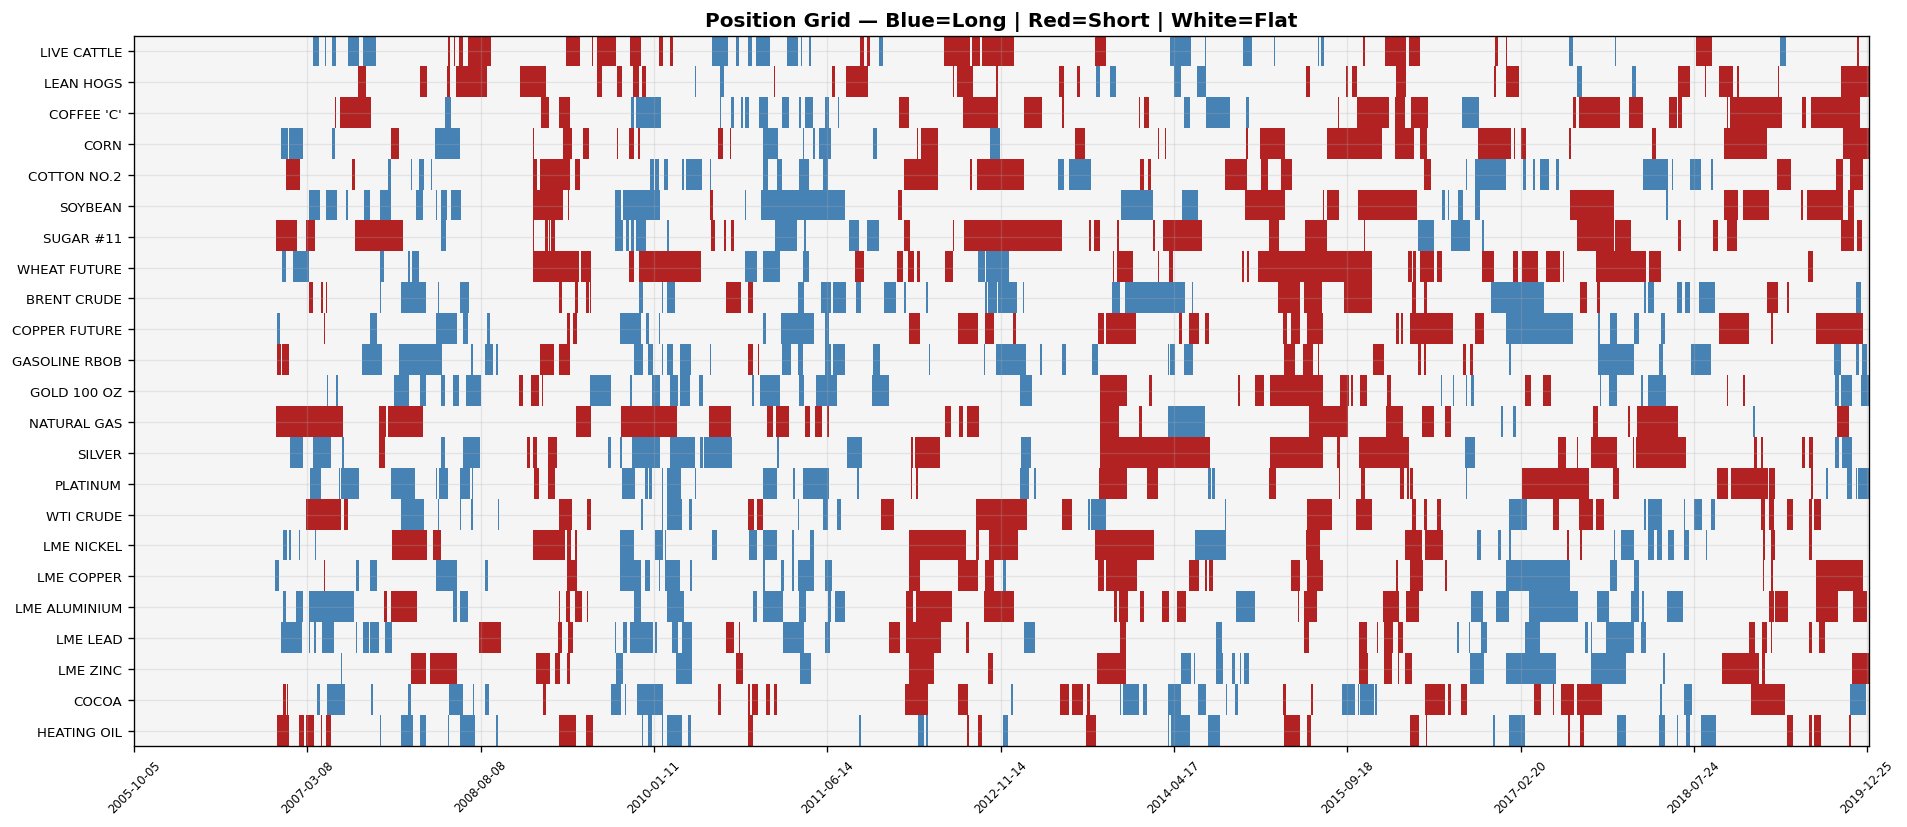

               Days Long  Days Short  Days Flat  % Long  % Short
LIVE CATTLE          295         478       2942     7.9     12.9
LEAN HOGS             84         520       3111     2.3     14.0
COFFEE 'C'           275         762       2678     7.4     20.5
CORN                 195         623       2897     5.2     16.8
COTTON NO.2          391         486       2838    10.5     13.1
SOYBEAN              554         593       2568    14.9     16.0
SUGAR #11            241         795       2679     6.5     21.4
WHEAT FUTURE         211         934       2570     5.7     25.1
BRENT CRUDE          619         296       2800    16.7      8.0
COPPER FUTURE        406         584       2725    10.9     15.7
GASOLINE RBOB        607         184       2924    16.3      5.0
GOLD 100 OZ          509         311       2895    13.7      8.4
NATURAL GAS           95         886       2734     2.6     23.8
SILVER               414         775       2526    11.1     20.9
PLATINUM             409 

In [87]:
import matplotlib.colors as mcolors

cmap  = mcolors.ListedColormap(['firebrick', 'whitesmoke', 'steelblue'])
norm  = mcolors.BoundaryNorm([-1.5, -0.5, 0.5, 1.5], cmap.N)
step  = max(1, len(positions) // 10)

fig, ax = plt.subplots(figsize=(16, 7))
ax.imshow(positions.T.values, aspect='auto', cmap=cmap, norm=norm, interpolation='none')
ax.set_yticks(range(len(positions.columns)))
ax.set_yticklabels(positions.columns, fontsize=8)
ax.set_xticks(range(0, len(positions), step))
ax.set_xticklabels([str(d.date()) for d in positions.index[::step]], rotation=45, fontsize=7)
ax.set_title('Position Grid — Blue=Long | Red=Short | White=Flat', fontweight='bold')
fig.tight_layout()
plt.show()

print(position_summary(positions))

The heatmap below is a visual audit of the final position grid over time.


### 4.2 Stop Loss Exit Analysis
Inspect where ATR stops and Bollinger Band exits would trigger for representative trades.


Exit breakdown — long trades  (SL_MULT = 3.0)
  SL         249  ( 53.2%)  ██████████████████████████████
  BB         184  ( 39.3%)  ██████████████████████
  Regime      35  (  7.5%)  ████


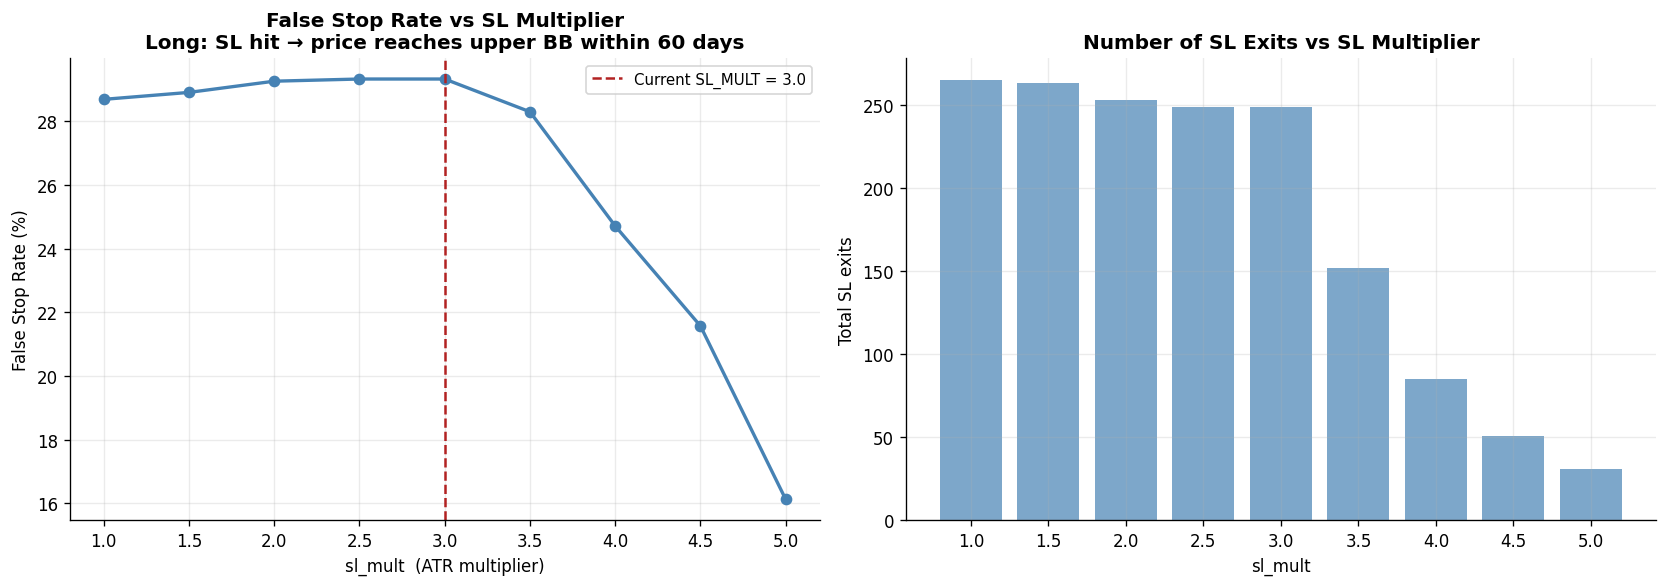


 sl_mult   SL exits   False stops   False rate
     1.0        265            76        28.7%
     1.5        263            76        28.9%
     2.0        253            74        29.2%
     2.5        249            73        29.3%
     3.0        249            73        29.3%
     3.5        152            43        28.3%
     4.0         85            21        24.7%
     4.5         51            11        21.6%
     5.0         31             5        16.1%


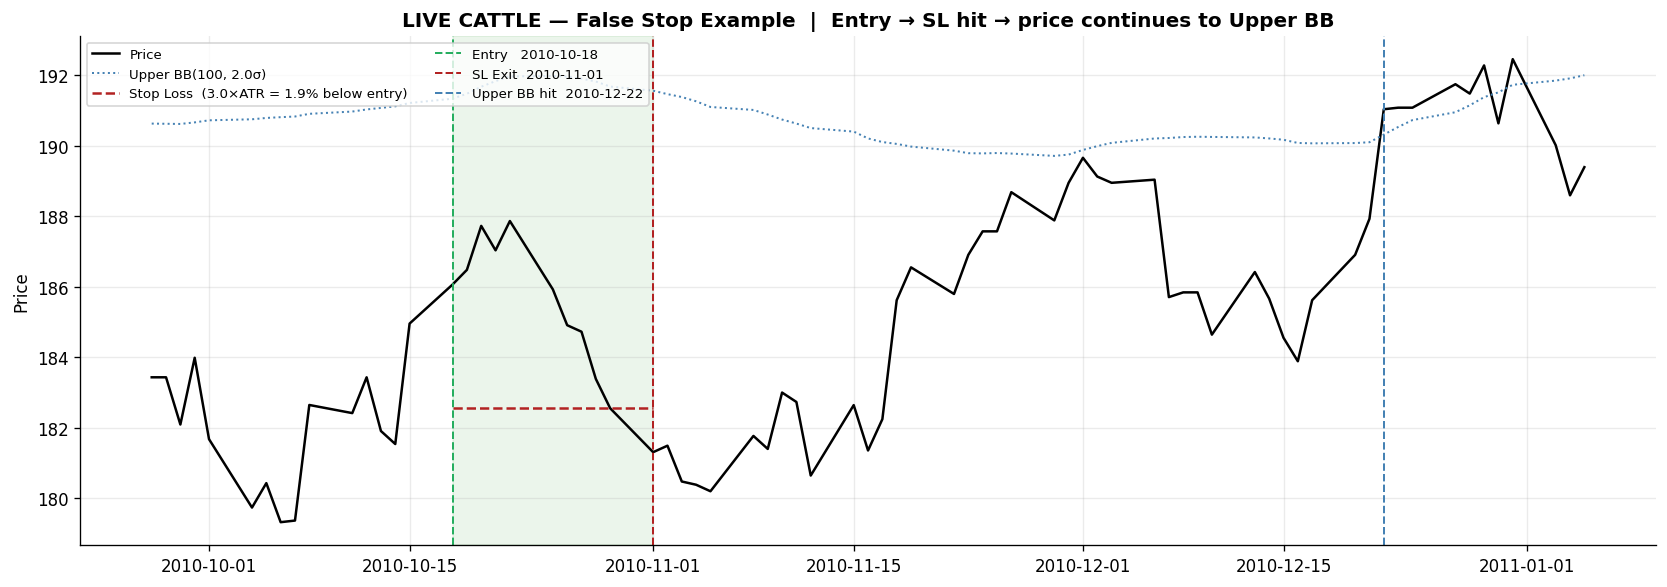

In [88]:
from indicators import atr_pct, bollinger_bands

atr_df     = atr_pct(prices, ATR_WINDOW)
_, ub_df, _ = bollinger_bands(prices, BB_WINDOW, BB_NUM_STD)

LOOKFORWARD  = 60
SL_MULT_VALS = [1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0]

# ── 1. Classify exits (long trades only) ──────────────────────────────────────
exit_stats = {'SL': 0, 'BB': 0, 'Regime': 0}
for col in positions.columns:
    pos   = positions[col]
    price = prices[col]
    atr   = atr_df[col]
    ub    = ub_df[col]

    prev  = pos.shift(1).fillna(0)
    entries = (pos == 1) & (prev != 1)
    exits   = (pos != 1) & (prev == 1)

    for e_t in entries[entries].index:
        later = exits[exits].index
        later = later[later > e_t]
        if len(later) == 0:
            continue
        x_t = later[0]

        ep  = price[e_t];  ea = atr[e_t]
        if np.isnan(ea) or ea < 1e-6:
            continue
        sl = ep * (1.0 - SL_MULT * ea)

        xp = price[x_t]
        if xp <= sl:
            exit_stats['SL'] += 1
        elif xp >= ub[x_t]:
            exit_stats['BB'] += 1
        else:
            exit_stats['Regime'] += 1

total_exits = sum(exit_stats.values())
print(f"Exit breakdown — long trades  (SL_MULT = {SL_MULT})")
for k, v in exit_stats.items():
    bar = '█' * int(v / max(exit_stats.values()) * 30)
    print(f"  {k:<8} {v:>5}  ({v/total_exits*100:5.1f}%)  {bar}")

# ── 2. False stop rate vs sl_mult ─────────────────────────────────────────────
false_rate = {}
for mult in SL_MULT_VALS:
    fs = 0; tot = 0
    for col in positions.columns:
        pos   = positions[col]
        price = prices[col]
        atr   = atr_df[col]
        ub    = ub_df[col]

        prev    = pos.shift(1).fillna(0)
        entries = (pos == 1) & (prev != 1)
        exits   = (pos != 1) & (prev == 1)

        for e_t in entries[entries].index:
            later = exits[exits].index
            later = later[later > e_t]
            if len(later) == 0:
                continue
            x_t = later[0]
            ep = price[e_t]; ea = atr[e_t]
            if np.isnan(ea) or ea < 1e-6:
                continue
            sl = ep * (1.0 - mult * ea)
            if price[x_t] > sl:
                continue
            tot += 1
            loc     = prices.index.get_loc(x_t)
            end_loc = min(loc + LOOKFORWARD, len(prices) - 1)
            fut     = prices.index[loc+1 : end_loc+1]
            if len(fut) and (price[fut] >= ub[fut]).any():
                fs += 1

    false_rate[mult] = {'fs': fs, 'tot': tot, 'rate': fs/tot*100 if tot else 0}

rates  = [false_rate[m]['rate'] for m in SL_MULT_VALS]
totals = [false_rate[m]['tot']  for m in SL_MULT_VALS]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(SL_MULT_VALS, rates, marker='o', color='steelblue', lw=2)
ax.axvline(SL_MULT, color='firebrick', lw=1.5, linestyle='--',
           label=f'Current SL_MULT = {SL_MULT}')
ax.set_xlabel('sl_mult  (ATR multiplier)')
ax.set_ylabel('False Stop Rate (%)')
ax.set_title('False Stop Rate vs SL Multiplier\n'
             'Long: SL hit → price reaches upper BB within 60 days', fontweight='bold')
ax.legend(fontsize=9); ax.spines[['top','right']].set_visible(False)

ax = axes[1]
ax.bar([str(m) for m in SL_MULT_VALS], totals, color='steelblue', alpha=0.7)
ax.set_xlabel('sl_mult'); ax.set_ylabel('Total SL exits')
ax.set_title('Number of SL Exits vs SL Multiplier', fontweight='bold')
ax.spines[['top','right']].set_visible(False)

fig.tight_layout(); plt.show()

print(f"\n{'sl_mult':>8}  {'SL exits':>9}  {'False stops':>12}  {'False rate':>11}")
for m in SL_MULT_VALS:
    r = false_rate[m]
    print(f"{m:>8.1f}  {r['tot']:>9}  {r['fs']:>12}  {r['rate']:>10.1f}%")

# ── 3. Example: false stop trade ──────────────────────────────────────────────
found = False
for col in positions.columns:
    if found: break
    pos   = positions[col]; price = prices[col]
    atr   = atr_df[col];    ub    = ub_df[col]
    prev  = pos.shift(1).fillna(0)
    entries = (pos == 1) & (prev != 1)
    exits   = (pos != 1) & (prev == 1)

    for e_t in entries[entries].index:
        later = exits[exits].index; later = later[later > e_t]
        if len(later) == 0: continue
        x_t = later[0]
        ep = price[e_t]; ea = atr[e_t]
        if np.isnan(ea) or ea < 1e-6: continue
        sl = ep * (1.0 - SL_MULT * ea)
        if price[x_t] > sl: continue
        loc     = prices.index.get_loc(x_t)
        end_loc = min(loc + LOOKFORWARD, len(prices) - 1)
        fut     = prices.index[loc+1 : end_loc+1]
        if len(fut) == 0: continue
        mask = (price[fut] >= ub[fut]).values
        if not mask.any(): continue
        bb_hit_t = fut[mask][0]

        s = max(0, prices.index.get_loc(e_t) - 15)
        e = min(len(prices)-1, prices.index.get_loc(bb_hit_t) + 10)
        idx = prices.index[s:e+1]

        fig, ax = plt.subplots(figsize=(14, 5))
        ax.plot(idx, price[idx], color='black', lw=1.5, label='Price')
        ax.plot(idx, ub[idx], color='steelblue', lw=1.2, linestyle=':',
                label=f'Upper BB({BB_WINDOW}, {BB_NUM_STD}σ)')
        ax.hlines(sl, e_t, x_t, colors='firebrick', lw=1.5, linestyle='--',
                  label=f'Stop Loss  ({SL_MULT}×ATR = {(ep-sl)/ep*100:.1f}% below entry)')
        ax.axvline(e_t,      color='#27ae60',   lw=1.2, linestyle='--',
                   label=f'Entry   {e_t.date()}')
        ax.axvline(x_t,      color='firebrick', lw=1.2, linestyle='--',
                   label=f'SL Exit  {x_t.date()}')
        ax.axvline(bb_hit_t, color='steelblue', lw=1.2, linestyle='--',
                   label=f'Upper BB hit  {bb_hit_t.date()}')
        ax.fill_between(idx, 0, 1,
                        where=((idx >= e_t) & (idx <= x_t)),
                        transform=ax.get_xaxis_transform(),
                        color='green', alpha=0.08)
        ax.set_title(f'{col} — False Stop Example  |  Entry → SL hit → price continues to Upper BB',
                     fontweight='bold')
        ax.legend(fontsize=8, loc='upper left', ncol=2)
        ax.set_ylabel('Price'); ax.spines[['top','right']].set_visible(False)
        fig.tight_layout(); plt.show()
        found = True; break

if not found:
    print("No false stop example found in data.")

### 4.3 ATR Stop Distance Investigation
Review stop-distance variation across commodities so the sizing assumptions are visible.


=== ATR(50) medio annuale per commodity (% del prezzo) ===
Lettura: un valore di 1.5 significa che la mossa giornaliera tipica
         è ~1.5% del prezzo. Con SAR_INITIAL_MULT=3.5 lo stop
         iniziale sarebbe 3.5 × 1.5% = 5.25% dal prezzo di entrata.



,LIVE CATTLE,LEAN HOGS,COFFEE 'C',CORN,COTTON NO.2,SOYBEAN,SUGAR #11,WHEAT FUTURE,BRENT CRUDE,COPPER FUTURE,...,SILVER,PLATINUM,WTI CRUDE,LME NICKEL,LME COPPER,LME ALUMINIUM,LME LEAD,LME ZINC,COCOA,HEATING OIL
Year,,,,,,,,,,,,,,,,,,,,,
2005,0.571,1.011,1.475,0.609,0.970,1.045,1.232,0.859,1.328,1.027,...,1.010,0.749,1.353,1.450,0.936,0.885,1.116,1.049,1.127,1.756
2006,0.658,1.006,1.226,1.291,0.967,0.922,1.707,1.327,1.327,1.682,...,1.876,1.061,1.335,1.892,1.677,1.413,1.598,1.931,1.049,1.561
2007,0.590,0.951,1.077,1.515,0.935,1.033,1.077,1.562,1.297,1.463,...,1.171,0.748,1.404,2.099,1.460,0.940,1.914,1.803,1.134,1.352
2008,0.734,1.162,1.406,1.848,1.600,1.818,1.894,2.357,2.165,1.981,...,2.124,1.823,2.237,2.439,1.884,1.324,2.642,2.380,1.603,1.953
2009,0.704,1.386,1.377,1.782,1.560,1.510,1.720,1.821,2.367,2.181,...,1.831,1.384,2.726,2.503,2.122,1.561,2.549,2.126,1.710,2.243
2010,0.591,1.030,1.371,1.403,1.329,0.945,2.223,1.646,1.292,1.330,...,1.445,0.973,1.370,1.779,1.348,1.269,1.880,1.904,1.203,1.307
2011,0.728,0.974,1.446,1.566,1.934,1.005,1.929,1.812,1.313,1.327,...,2.083,0.937,1.527,1.669,1.311,1.030,1.695,1.501,1.323,1.228
2012,0.584,0.886,1.411,1.322,1.231,1.079,1.186,1.516,1.060,1.074,...,1.452,0.993,1.183,1.326,1.013,0.978,1.269,1.105,1.546,0.953
2013,0.420,0.687,1.212,1.114,0.893,0.895,0.813,0.927,0.819,0.870,...,1.394,0.985,0.907,1.061,0.847,0.842,0.928,0.784,0.937,0.803



=== Ranking ATR medio — intero campione 2005-2019 ===
(più alto = più volatile = stop più lontano per stesso moltiplicatore)

  NATURAL GAS            ATR=2.142%   stop@3.5x=7.50%   stop@6.0x=12.85%   ████████████████████████████████████████████████████████████████
  LME NICKEL             ATR=1.625%   stop@3.5x=5.69%   stop@6.0x=9.75%   ████████████████████████████████████████████████
  GASOLINE RBOB          ATR=1.585%   stop@3.5x=5.55%   stop@6.0x=9.51%   ███████████████████████████████████████████████
  WTI CRUDE              ATR=1.574%   stop@3.5x=5.51%   stop@6.0x=9.44%   ███████████████████████████████████████████████
  LME LEAD               ATR=1.490%   stop@3.5x=5.21%   stop@6.0x=8.94%   ████████████████████████████████████████████
  WHEAT FUTURE           ATR=1.457%   stop@3.5x=5.10%   stop@6.0x=8.74%   ███████████████████████████████████████████
  BRENT CRUDE            ATR=1.453%   stop@3.5x=5.09%   stop@6.0x=8.72%   ███████████████████████████████████████████
  SUGAR #11

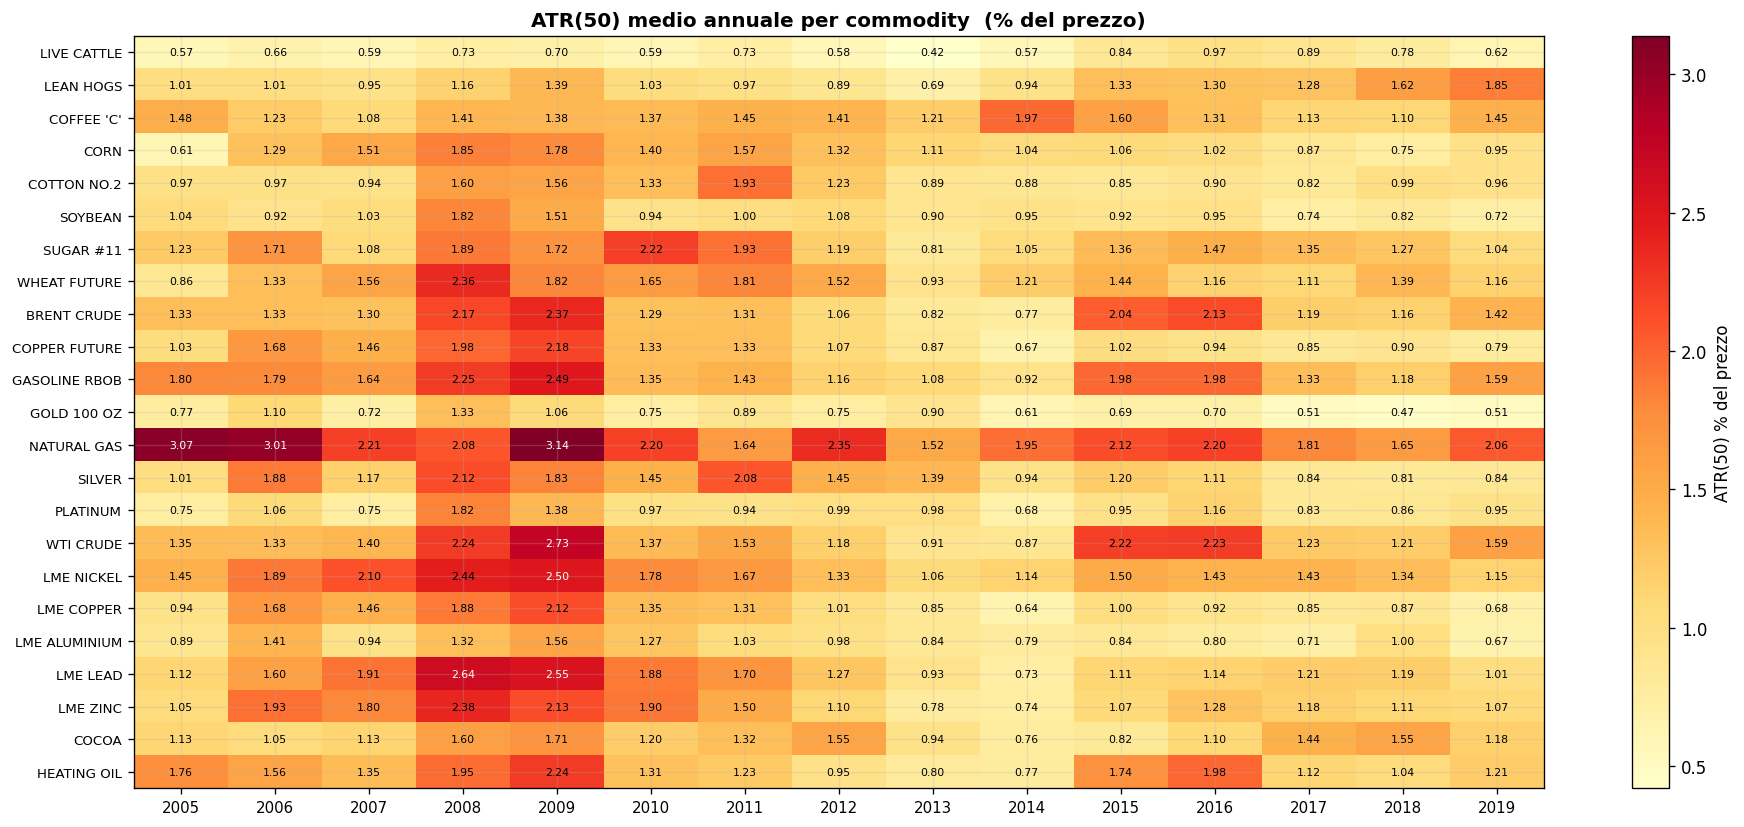

In [89]:
from indicators import atr_pct

# ── ATR(50) rolling — percentuale del prezzo ───────────────────────────────────
# ATR_pct = media mobile (50gg) delle variazioni assolute giornaliere / prezzo
# Rappresenta la volatilità giornaliera tipica come % del prezzo.
# Lo stop SAR iniziale = SAR_INITIAL_MULT × ATR_pct dal prezzo di entrata.

atr50 = atr_pct(prices, window=50)

# ── Media annuale ATR(50) per ogni commodity ───────────────────────────────────
atr_annual = (
    atr50
    .groupby(atr50.index.year)
    .mean()
    .mul(100)          # → percentuale
    .round(3)
)
atr_annual.index.name = 'Year'

print('=== ATR(50) medio annuale per commodity (% del prezzo) ===')
print('Lettura: un valore di 1.5 significa che la mossa giornaliera tipica')
print('         è ~1.5% del prezzo. Con SAR_INITIAL_MULT=3.5 lo stop')
print('         iniziale sarebbe 3.5 × 1.5% = 5.25% dal prezzo di entrata.\n')
display(atr_annual)

# ── Media sull'intero campione per commodity ───────────────────────────────────
atr_mean = atr50.mean().mul(100).round(3).sort_values(ascending=False)
atr_mean.name = 'ATR(50) medio % (intero campione)'

print('\n=== Ranking ATR medio — intero campione 2005-2019 ===')
print('(più alto = più volatile = stop più lontano per stesso moltiplicatore)\n')
for commodity, val in atr_mean.items():
    stop_35 = val * 3.5
    stop_60 = val * 6.0
    bar = '█' * int(val * 30)
    print(f'  {commodity:<22} ATR={val:.3f}%   '
          f'stop@3.5x={stop_35:.2f}%   stop@6.0x={stop_60:.2f}%   {bar}')

# ── Heatmap ATR annuale ────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

fig, ax = plt.subplots(figsize=(16, 7))
im = ax.imshow(atr_annual.T.values, aspect='auto', cmap='YlOrRd')

ax.set_xticks(range(len(atr_annual.index)))
ax.set_xticklabels(atr_annual.index, fontsize=9)
ax.set_yticks(range(len(atr_annual.columns)))
ax.set_yticklabels(atr_annual.columns, fontsize=8)

for i in range(len(atr_annual.columns)):
    for j in range(len(atr_annual.index)):
        val = atr_annual.iloc[j, i]
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=6.5, color='black' if val < 2.5 else 'white')

plt.colorbar(im, ax=ax, label='ATR(50) % del prezzo')
ax.set_title('ATR(50) medio annuale per commodity  (% del prezzo)',
             fontweight='bold', fontsize=12)
fig.tight_layout()
plt.show()

## 5. Performance And Robustness
Compare the baseline strategy against the equal-weight factor using summary statistics and stability charts.

### 5.1 Summary Statistics
Report annualised return, volatility, Sharpe, drawdown, turnover, and trade counts.


In [90]:
stats = pd.concat([
    performance_stats(port_r, label='Baseline Strategy',
                      factor=factor, weights=weights, positions=positions),
    performance_stats(factor.reindex(port_r.index).dropna(), label='EW Factor'),
], axis=1).T

stats

,Ann. Return %,Ann. Vol %,Sharpe,Sortino,Calmar,Max DD %,Skewness,Hit Rate,Num Trades,Trades / Year,Ann. Turnover %,Alpha (ann) %,Beta,R²
Baseline Strategy,1.78,15.98,0.111,0.139,0.040,-44.36,-0.434,0.456,955.0,64.8,1230.9,1.87,-0.074,0.005
EW Factor,1.23,15.65,0.078,0.106,0.023,-52.91,-0.217,0.508,NaN,NaN,NaN,NaN,NaN,NaN


### 5.2 Rolling Sharpe
Plot one-year rolling Sharpe to show whether performance is stable or concentrated in short windows.


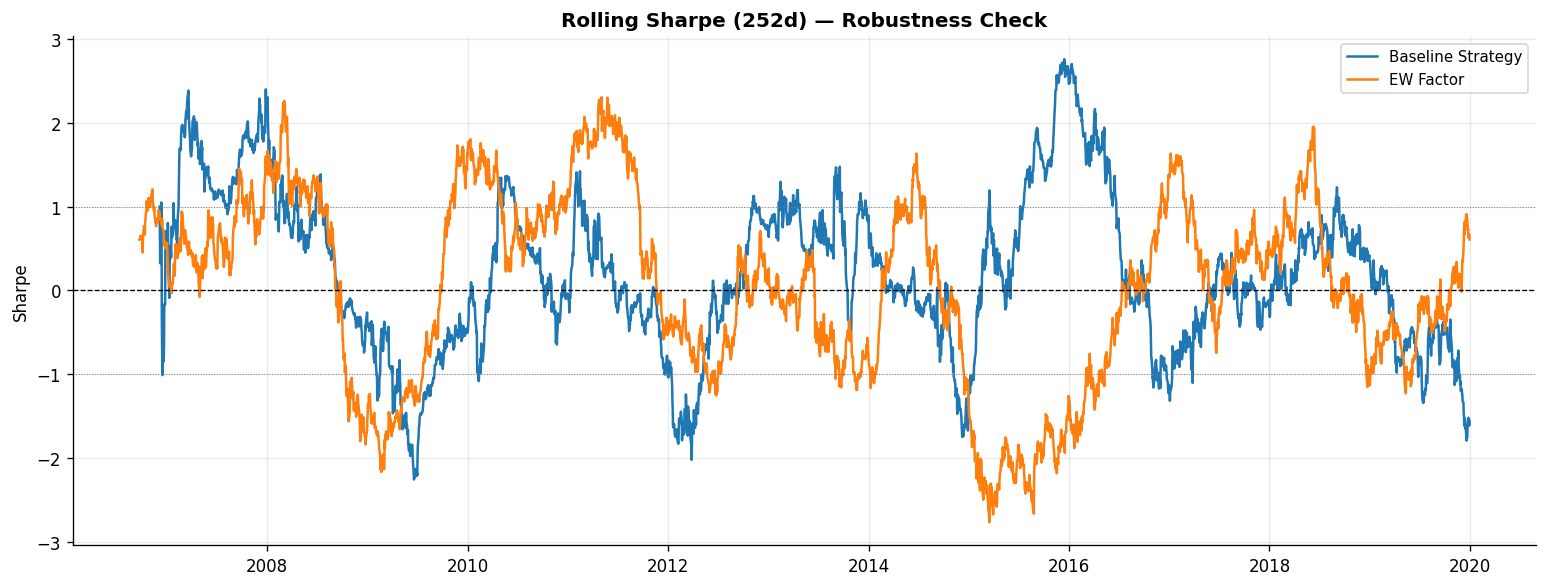

,Baseline Strategy,EW Factor
Date,,
2006-09-22,NaN,0.604886
2006-09-25,NaN,0.616444
2006-09-26,NaN,0.637668
2006-09-27,NaN,0.652278
2006-09-28,NaN,0.613839
...,...,...
2019-12-25,-1.552748,0.718404
2019-12-26,-1.535436,0.729792
2019-12-27,-1.521006,0.630872


In [91]:
plot_rolling_sharpe(
    {'Baseline Strategy': port_r, 'EW Factor': factor.reindex(port_r.index)},
    window=252,
)

### 5.3 Cumulative Returns
Plot log cumulative returns for the baseline strategy and the equal-weight commodity factor.


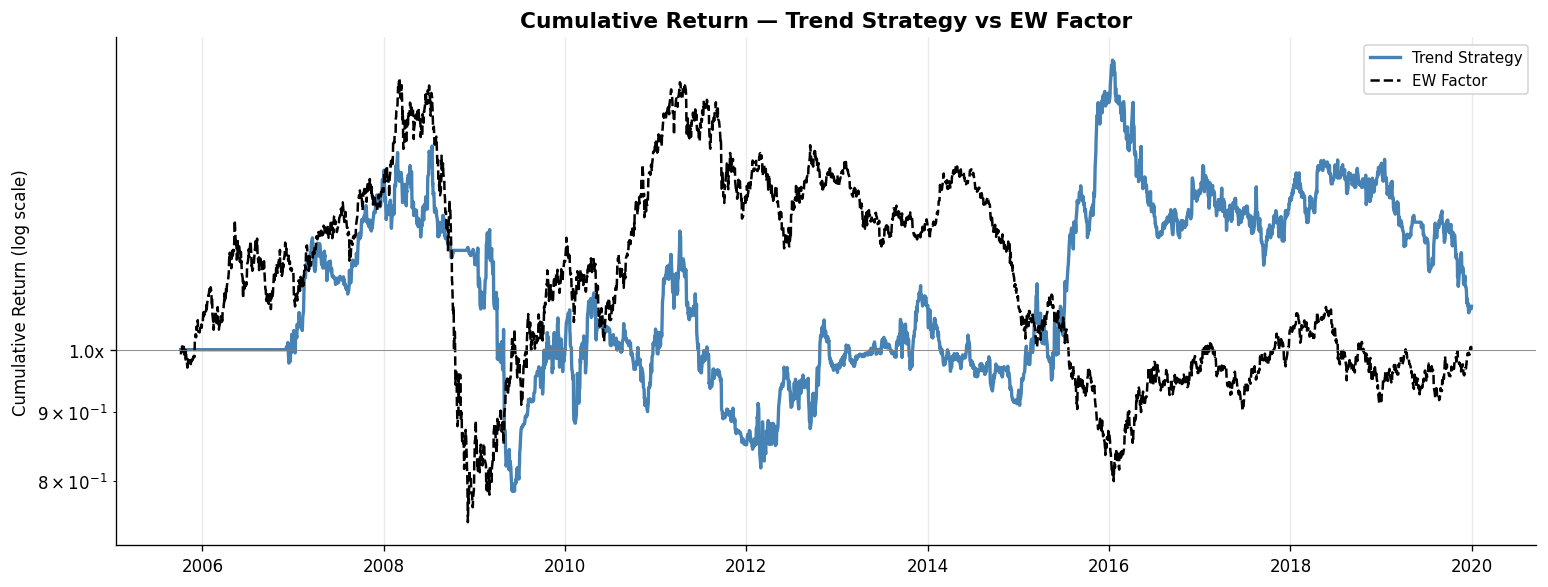

In [92]:
cum_strat  = (1 + port_r.dropna()).cumprod()
cum_factor = (1 + factor.reindex(port_r.index).dropna()).cumprod()

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(cum_strat.index,  cum_strat.values,  color='steelblue', lw=2.0, label='Trend Strategy')
ax.plot(cum_factor.index, cum_factor.values, color='black',     lw=1.5, linestyle='--', label='EW Factor')
ax.axhline(1, color='grey', lw=0.5)
ax.set_yscale('log')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}x'))
ax.set_title('Cumulative Return — Trend Strategy vs EW Factor', fontsize=13, fontweight='bold')
ax.set_ylabel('Cumulative Return (log scale)')
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
plt.show()

### 5.4 Sector Contribution
Break portfolio returns into sector-level contribution and then show the final position summary.


,Ann. Contribution %,Ann. Vol %,Sharpe
Agri & livestock,1.71,8.09,0.211
Energy,0.35,7.00,0.049
Metals,-0.27,9.82,-0.028


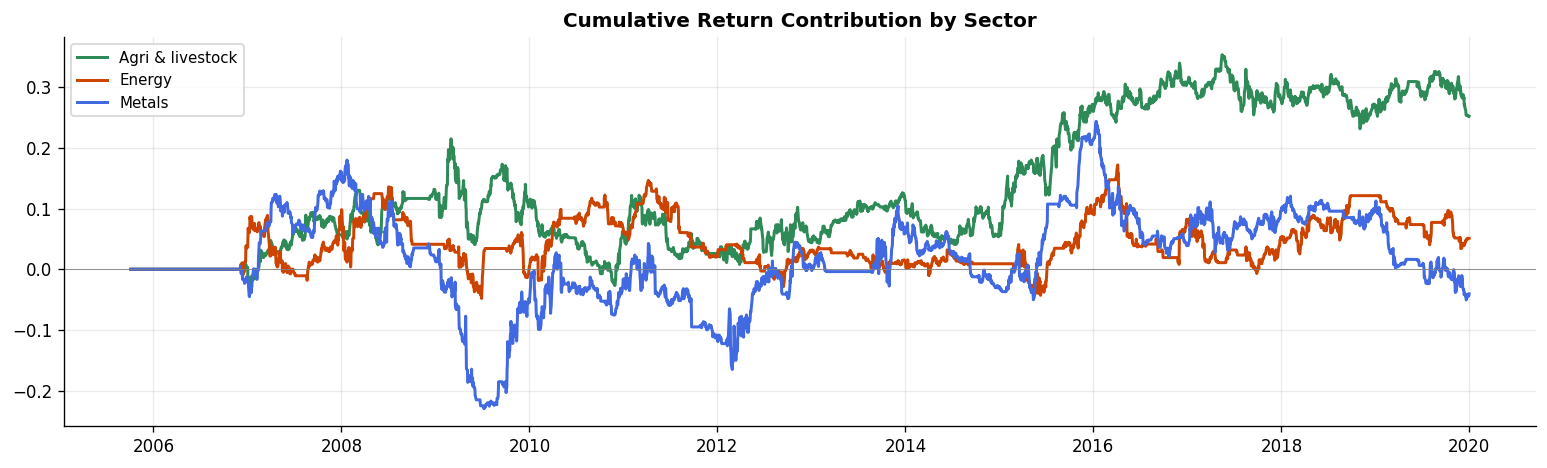

In [93]:
sc = sector_contribution(weights, returns, assets)

sc_summary = pd.DataFrame({
    'Ann. Contribution %' : (sc.mean() * 252 * 100).round(2),
    'Ann. Vol %'          : (sc.std()  * np.sqrt(252) * 100).round(2),
    'Sharpe'              : ((sc.mean() * 252) / (sc.std() * np.sqrt(252))).round(3),
})
display(sc_summary)

sector_colours = {'Agri & livestock': '#2e8b57', 'Energy': '#cc4400', 'Metals': '#4169e1'}
fig, ax = plt.subplots(figsize=(13, 4))
for col in sc.cumsum().columns:
    ax.plot(sc.cumsum().index, sc.cumsum()[col],
            color=sector_colours.get(col, 'grey'), lw=1.8, label=col)
ax.axhline(0, color='grey', lw=0.5)
ax.set_title('Cumulative Return Contribution by Sector', fontweight='bold')
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
plt.show()

In [94]:
position_summary(positions)

,Days Long,Days Short,Days Flat,% Long,% Short
LIVE CATTLE,295,478,2942,7.9,12.9
LEAN HOGS,84,520,3111,2.3,14.0
COFFEE 'C',275,762,2678,7.4,20.5
CORN,195,623,2897,5.2,16.8
COTTON NO.2,391,486,2838,10.5,13.1
SOYBEAN,554,593,2568,14.9,16.0
SUGAR #11,241,795,2679,6.5,21.4
WHEAT FUTURE,211,934,2570,5.7,25.1
BRENT CRUDE,619,296,2800,16.7,8.0
COPPER FUTURE,406,584,2725,10.9,15.7


## 6. Final Summary Notes
Task 1 is the unchanged baseline: single-lookback trend regime, EMA/RSI entry timing, fixed ATR stop, Bollinger Band exit, ATR sizing, and a gross leverage cap. Re-run from the top after parameter edits so every diagnostic reflects the same strategy instance.
